In [410]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot  as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier)
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (cross_val_score, StratifiedKFold, GridSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, RocCurveDisplay, ConfusionMatrixDisplay
import joblib

In [411]:
np.random.seed(42)

dataset = pd.read_csv("dataset_heart_attack.csv")

print("shape : ", dataset.shape)

shape :  (294, 14)


Le dataset utilisé est composé de 294 individus et de 14 attributs.

In [412]:
dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,52,1,4,160,331,0,0,94,1,2.5,?,?,?,1
290,54,0,3,130,294,0,1,100,1,0.0,2,?,?,1
291,56,1,4,155,342,1,0,150,1,3.0,2,?,?,1
292,58,0,2,180,393,0,0,110,1,1.0,2,?,7,1


'ca', 'thal' et 'slope' ont respectivement 99%, 90.5% et 64.6% de valeurs manquantes :
trop incomplètes pour être imputées de façon fiable, on les supprime.
Les autres colonnes ont moins de 8% de NaN : elles seront imputées dans le pipeline.

In [413]:
dataset = dataset.drop(columns=["slope", "ca", "thal"])
dataset = dataset.drop_duplicates()
dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
0,28,1,2,130,132,0,2,185,0,0.0,0
1,29,1,2,120,243,0,0,160,0,0.0,0
2,29,1,2,140,?,0,0,170,0,0.0,0
3,30,0,1,170,237,0,1,170,0,0.0,0
4,31,0,2,100,219,0,1,150,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...
289,52,1,4,160,331,0,0,94,1,2.5,1
290,54,0,3,130,294,0,1,100,1,0.0,1
291,56,1,4,155,342,1,0,150,1,3.0,1
292,58,0,2,180,393,0,0,110,1,1.0,1


In [414]:
print("shape of dataset: ", dataset.shape)
print("Colonnes dupliquées", dataset.duplicated().sum())

shape of dataset:  (293, 11)
Colonnes dupliquées 0


Les lignes identiques ont été supprimés ( On passe de 294 à 293 individus).

In [415]:
print("DATASET INFO")
dataset.info()

DATASET INFO
<class 'pandas.DataFrame'>
Index: 293 entries, 0 to 293
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         293 non-null    int64  
 1   sex         293 non-null    int64  
 2   cp          293 non-null    int64  
 3   trestbps    293 non-null    str    
 4   chol        293 non-null    str    
 5   fbs         293 non-null    str    
 6   restecg     293 non-null    str    
 7   thalach     293 non-null    str    
 8   exang       293 non-null    str    
 9   oldpeak     293 non-null    float64
 10  num         293 non-null    int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 31.1 KB


Aucune valeur ne manque dans l'entiereté des lignes. Cependant 6 colonnes ('trestbps', 'chol', 'fbs', restecg', 'thalach', 'exang', 'exang') sont typées en chaînes de caractères alors que ce sont des valeurs numériques. Cela est causé par des "?" pour représenter les valeurs manquantes.

In [416]:
dataset.describe()

,age,sex,cp,oldpeak,num
count,293.000000,293.000000,293.000000,293.000000,293.000000
mean,47.822526,0.726962,2.986348,0.588055,0.361775
std,7.824875,0.446282,0.965049,0.909554,0.481336
min,28.000000,0.000000,1.000000,0.000000,0.000000
25%,42.000000,0.000000,2.000000,0.000000,0.000000
50%,49.000000,1.000000,3.000000,0.000000,0.000000
75%,54.000000,1.000000,4.000000,1.000000,1.000000
max,66.000000,1.000000,4.000000,5.000000,1.000000


Seulement 5 variables apparaissent ici car les 6 autres sont typés en chaînes de caractères.Le dataset comporte des individus de 28 à 66 ans. On voit que les variables 'sex' et 'cp' sont des variables catégorielles (sex:0/1 et cp:1 à 4). La moyenne de 'oldpeak' est de 0,58 ce qui suggère une répartition asymétrique.

In [417]:
dataset.columns = dataset.columns.str.strip()
print(dataset.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'num']


In [418]:
dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
0,28,1,2,130,132,0,2,185,0,0.0,0
1,29,1,2,120,243,0,0,160,0,0.0,0
2,29,1,2,140,?,0,0,170,0,0.0,0
3,30,0,1,170,237,0,1,170,0,0.0,0
4,31,0,2,100,219,0,1,150,0,0.0,0


In [419]:
dataset = dataset.replace("?", np.nan)
dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
0,28,1,2,130,132,0,2,185,0,0.0,0
1,29,1,2,120,243,0,0,160,0,0.0,0
2,29,1,2,140,NaN,0,0,170,0,0.0,0
3,30,0,1,170,237,0,1,170,0,0.0,0
4,31,0,2,100,219,0,1,150,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...
289,52,1,4,160,331,0,0,94,1,2.5,1
290,54,0,3,130,294,0,1,100,1,0.0,1
291,56,1,4,155,342,1,0,150,1,3.0,1
292,58,0,2,180,393,0,0,110,1,1.0,1


On remplace les "?" par des NaN pour pouvoir changer le type des variables en numérique.

In [420]:
for col in dataset.columns:
    dataset[col] = pd.to_numeric(dataset[col], errors="coerce")

In [421]:
dataset.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
count,293.000000,293.000000,293.000000,292.000000,271.000000,285.000000,292.000000,292.000000,292.000000,293.000000,293.000000
mean,47.822526,0.726962,2.986348,132.660959,250.848708,0.070175,0.219178,139.058219,0.304795,0.588055,0.361775
std,7.824875,0.446282,0.965049,17.606957,67.657711,0.255892,0.461481,23.598446,0.461111,0.909554,0.481336
min,28.000000,0.000000,1.000000,92.000000,85.000000,0.000000,0.000000,82.000000,0.000000,0.000000,0.000000
25%,42.000000,0.000000,2.000000,120.000000,209.000000,0.000000,0.000000,122.000000,0.000000,0.000000,0.000000
50%,49.000000,1.000000,3.000000,130.000000,243.000000,0.000000,0.000000,140.000000,0.000000,0.000000,0.000000
75%,54.000000,1.000000,4.000000,140.000000,282.500000,0.000000,0.000000,155.000000,1.000000,1.000000,1.000000
max,66.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,190.000000,1.000000,5.000000,1.000000


Les 11 variables apparaissent ici donc elles sont toutes de types numériques.
Les variables 'fbs', 'exang' et 'restecg' sont des variables catégorielles (fbs: 0/1, exang:0/1, restecg: 0 à 2).
Au total on a donc 5 variables catégorielles au total.

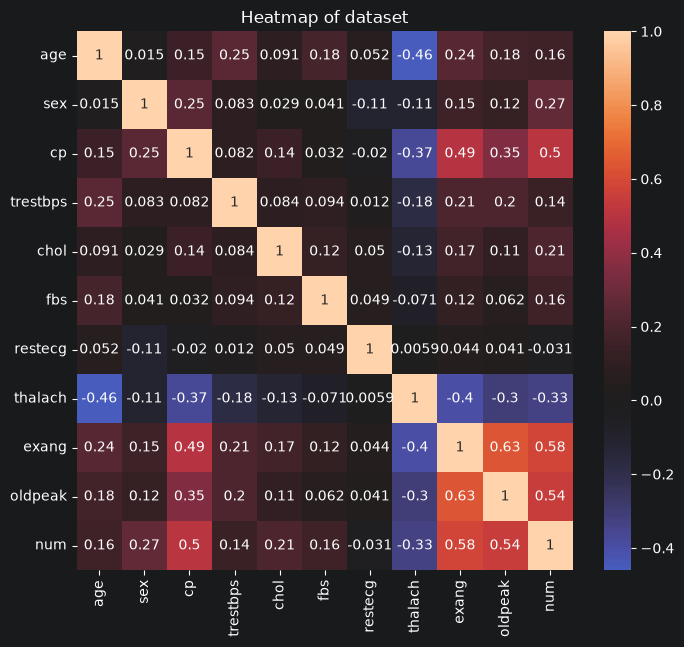

In [422]:
plt.figure(figsize=(8,7))
numeric_features = dataset.select_dtypes(include="number")
corr_matrix = numeric_features.corr()
sns.heatmap(corr_matrix, center=0, annot=True)
plt.title("Heatmap of dataset")
plt.show()

les 3 variables les plus corrélées à la variable cible 'num' sont les variables 'exang':0,58, 'oldpeak':0,54 et 'cp':0,5. Ces variables sont les plus représentatives pour prédire la présence d'une maladie cardiaque. Les variables les moins corrélées sont 'restecg': -0,03, 'trestbps': 0,14 et 'fbs': 0,16.

In [423]:
X = dataset.drop(columns="num")
y = dataset["num"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

On enlève la variable cible du dataset afin de séparer les individus en 2 groupes (test et train) pour entraîner le modèle et l'évaluer. On utilise 80% des individus pour l'entraînement.

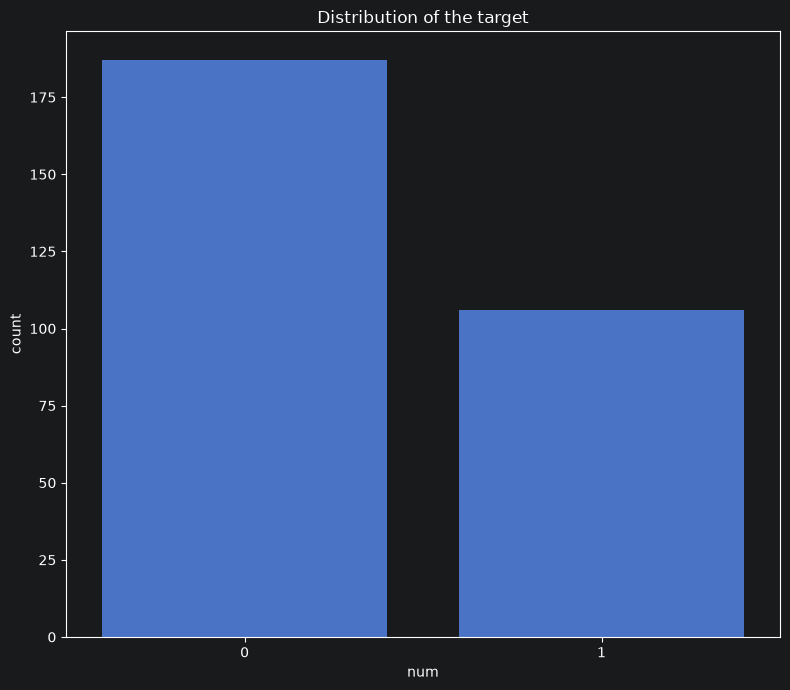

In [424]:
plt.figure(figsize=(8,7))
sns.countplot(data=dataset,x="num")
plt.title("Distribution of the target")
plt.tight_layout()
plt.show()

On remarque que la répartition des données de la cible comportent un léger désequilibre.

In [425]:
dataset.skew()

age        -0.282281
sex        -1.024116
cp         -0.225827
trestbps    0.737336
chol        1.433386
fbs         3.383166
restecg     1.977815
thalach    -0.080368
exang       0.852514
oldpeak     1.543805
num         0.578287
dtype: float64

les variables 'age', 'cp' et 'thalach' ont une Skewness entre -0,5 et 0,5 donc ont une distribution plutôt symétrique (on peut noté que la skewness de 'thalach' est quasi nulle donc elle se rapproche fortement d'une distribution normale).

In [426]:
columns_cat = ['cp','restecg']
columns_num = [c for c in X_train.columns if c not in columns_cat]

On a vu que 5 variables sont des variables catégoriques, elles se traitent différemment des variables numériques.
3 de ces variables sont binaires, les standardiser non donc pas d'incidence, on peut donc les placer dand la liste des colonnes numériques. On place donc seulement les variables 'cp' et 'restecg' dans la liste des variables catégorielles pour les encoder dans un one-hot.

In [427]:
pipeline_num = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

pipeline_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", pipeline_num, columns_num),
    ("cat", pipeline_cat, columns_cat)
])

On crée deux Pipelines (pour les colonnes numériques et pour les colonnes catégorielles) afin de traiter sans fuites les objets.
La majorité des variables numériques ont une distribution asymétrique donc j'ai fais le choix d'utiliser la médiane pour la stratégie.

In [428]:
baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_baseline = cross_val_score(baseline, X_train, y_train, cv=cv, scoring="f1")
print(f"Logistic Regression F1 score: {scores_baseline.mean():.3f} (+/- {scores_baseline.std():.3f})")

Logistic Regression F1 score: 0.752 (+/- 0.067)


On entraîne un premier modèle basé sur la régression logistique, ce modèle à un score F1 d'environ 0,75.

In [429]:
models = {
    "Gradient Boosting Classifier": GradientBoostingClassifier(random_state=42) ,
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
    }

On initialise d'autres modèles afin de choisir le meilleur.

In [430]:
resultats = []

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    resultats.append({"model": name, "f1_mean": scores.mean(), "f1_std": scores.std()})
    print(f"{name} F1 score: {scores.mean():.3f} +/- {scores.std():.3f}")


Gradient Boosting Classifier F1 score: 0.684 +/- 0.077
Random Forest F1 score: 0.725 +/- 0.039


les modèles ont un score F1 inférieur (0,68 pour Gradient Boosting Classifier et 0,73 pour Random Forest) au modèle de régression logistique. Le meilleur modèle est donc la régression logistique.

In [431]:
dummy = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

scores_dummy = cross_val_score(dummy, X_train, y_train, cv=cv, scoring="f1")

print(f"DummyClassifier: {scores_dummy.mean():.3f} +/- {scores_dummy.std():.3f}")

DummyClassifier: 0.000 +/- 0.000


Grâce au DummyClassifier on explique pourquoi on évalue la qualité d'un modèle par son score F1 plutôt que par sa précision. En effet notre modèle dummy prédit toujours la classe majoritaire donc il obtient une précision de 64% or son score F1 est de 0. Sur un dataset déséquilibré, le score F1 est plus représentatif car il évalue la précision sur une classe uniquement (la classe des malades). Ainsi le modèle dummy ne détecte aucun malade (ce qui est cohérent avec le résultat trouvé).

In [432]:
param_grid = {
    "model__C" : [0.01,0.1,1,10],
}

grid = GridSearchCV(baseline, param_grid=param_grid, cv=cv,scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information p

In [433]:
print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score F1 (CV) :", grid.best_score_)

Meilleurs paramètres : {'model__C': 0.1}
Meilleur score F1 (CV) : 0.758300047190481


On cherche les meilleurs hyperparamètres afin d'optimiser notre modèle.

              precision    recall  f1-score   support

           0       0.81      0.89      0.85        38
           1       0.76      0.62      0.68        21

    accuracy                           0.80        59
   macro avg       0.79      0.76      0.77        59
weighted avg       0.79      0.80      0.79        59



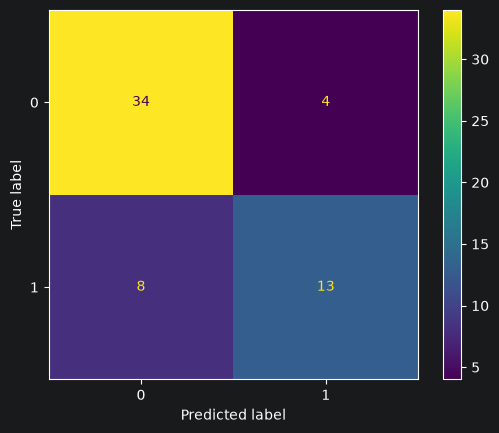

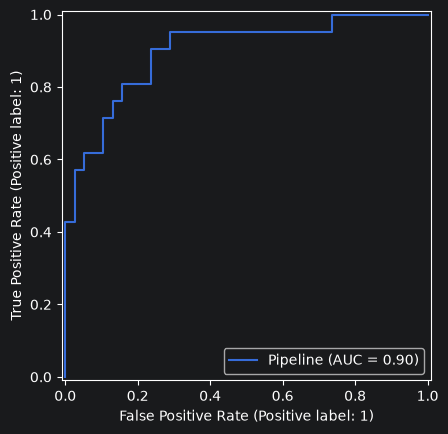

In [434]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
RocCurveDisplay.from_estimator(best_model, X_test, y_test)

On remarque ici que le recall de la classe 1 (c'est-à-dire les individus malades) est de 0,62. Donc 38% des vrais malades ne sont pas repérés par le modèle. Médicalement, le modèle n'est pas fiable.

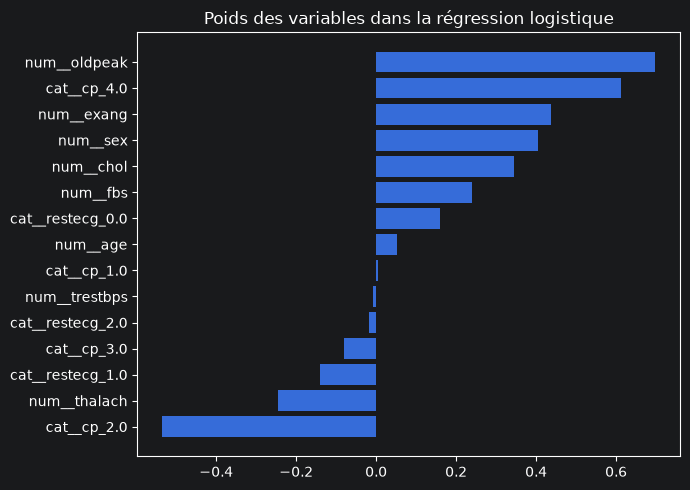

In [435]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
coefs = best_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs}).sort_values("coefficient")

plt.figure(figsize=(7,5))
plt.barh(coef_df["feature"], coef_df["coefficient"])
plt.title("Poids des variables dans la régression logistique")
plt.tight_layout()
plt.show()

Les variables qui pèsent le plus sont 'oldpeak', 'cp_4' et 'exang'. Ce sont les variables qui sont le plus associées au risque.
au contraire, 'cp_2' n'ai pas associé au risque.

In [436]:
baseline_weighted = Pipeline([
    ("preprocessor", preprocessor ),
    ("model", LogisticRegression(max_iter=1000,class_weight="balanced"))
])

scores_recall = cross_val_score(baseline_weighted, X_train, y_train, cv=cv, scoring="recall")
print(f"Recall (classe 1) avec class_weight='balanced': {scores_recall.mean():.3f}")


Recall (classe 1) avec class_weight='balanced': 0.800


En paramétrant la régression logistique avec class_weight='balanced' le recall est de 0,8. Ainsi le modèle rate 21% des malades. Même si le modèle reste toujours médicalement mauvais, ce paramètre a permis de l'améliorer en passant de 38% à 20% de malades inaperçus.

In [437]:
joblib.dump(best_model, "model_heart_attack.pkl")

['model_heart_attack.pkl']

On enregistre le modèle.

In [438]:
resultats.append({"model": "Logistic Regression", "f1_mean": scores_baseline.mean(), "f1_std": scores_baseline.std()})
resultats.append({"model": "Dummy", "f1_mean": 0.0, "f1_std": 0.0})

pd.DataFrame(resultats).sort_values("f1_mean", ascending=False)

,model,f1_mean,f1_std
2,Logistic Regression,0.752324,0.067300
1,Random Forest,0.724966,0.039156
0,Gradient Boosting Classifier,0.684411,0.077472
3,Dummy,0.000000,0.000000


Après avoir entraîné différents modèles, on a retenu le plus performant(la régression logistique). Le recall de ce modèle est de 0,8 au mieux donc il est insuffisant pour un usage médical. On peut aussi souligner le fait que l'on a utilisé un petit dataset (seulement 293 lignes) et qu'on a supprimé 3 colonnes ('ca', 'thal' et 'slope') qui auraient potentiellement pu contribuer à avoir un modèle plus précis.